## CNN Fashion MNIST

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import numpy as np

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [31]:
# Deterministic settings
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
# torch.cuda.manual_seed_all(SEED)  # if you use many GPUs
np.random.seed(SEED)
random.seed(SEED)

# Set to True, PyTorch will force the use of deterministic cuDNN algorithms (for operations like convolutions, pooling)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [33]:
# 1. changes the image size to 64x64
# 2. converts the PIL image with a pixel range of [0, 255] to a float tensor of shape (C, H, W) with a range [0.0, 1.0]
# 3. normalize: image = (image - mean) / std; value provided for only one color channel (mean_gray,), the same for std

transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # range of [-1, 1]
])

In [34]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

In [35]:
class_names = train_dataset.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [36]:
# Dataloaders

BATCH_SIZE = 32

# worker_init_fn - setting a random number generator for each data loading worker
# If you don't set a seed in each worker, random operations 
# (e.g. data augmentation, worker shuffle) may be different each time you run them
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          worker_init_fn=lambda worker_id: np.random.seed(SEED + worker_id))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
print(f"Dataloaders: {train_loader, test_loader}")
print(f"Length of train dataloader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_loader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000002B7A74BB050>, <torch.utils.data.dataloader.DataLoader object at 0x000002B7A74BAE50>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [38]:
train_features_batch, train_labels_batch = next(iter(train_loader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 64, 64]), torch.Size([32]))

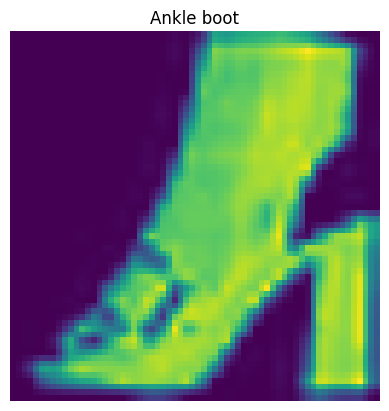

In [41]:
# show a sample
torch.manual_seed(42)
random_index = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_index], train_labels_batch[random_index]

plt.imshow(img.squeeze())
plt.title(class_names[label])
plt.axis("off")
plt.show()

In [188]:
# CNN TinyVGG Architecture
# https://poloclub.github.io/cnn-explainer/

# first version: TinyVGG
# second version TinyVGG with regularization: Dropout + BatchNorm
# second version TinyVGG with regularization + hidden neurons=32

class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units:int, output_shape: int):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,  # default
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2, stride=2
            ),  # default stride value is same as kernel_size
            nn.Dropout(0.1),  # lite regulariztion
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),  # lite regulariztion
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=128),
            nn.ReLU(),
            nn.Dropout(0.5),  
            nn.Linear(128, output_shape),
        )

    def forward(self, x:torch.Tensor):
        x = self.block_1(x)
        #print(x.shape)
        x = self.block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x

torch.manual_seed(42)
model = TinyVGG(input_shape=1,
                hidden_units=16,
                output_shape=(len(class_names))).to(device)
model        

TinyVGG(
  (block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.1, inplace=False)
  )
  (block_2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dr

In [189]:
# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 1, 64, 64))   # [batch_size, color_channels, height, width]
test_image = images[0]
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")

Image batch shape: torch.Size([32, 1, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([1, 64, 64]) -> [color_channels, height, width]


In [190]:
model(images)

tensor([[ 0.0621,  0.1461, -0.1909, -0.4795, -0.4634, -0.1117, -0.3150,  0.0257,
         -0.6094,  0.1928],
        [ 0.1263,  0.0643,  0.1674, -0.5325, -0.0656, -0.2369, -0.1774,  0.2823,
          0.0880,  0.7429],
        [ 0.4071, -0.0660, -0.7562, -0.2640, -0.0504, -0.0174,  0.2039, -0.2490,
         -0.2798,  0.5841],
        [ 0.6351,  0.0030, -0.3600, -0.1223, -0.5283,  0.4703,  0.0506,  0.4155,
         -0.5268,  0.3837],
        [ 0.2517, -0.2801, -0.4530, -0.0033, -0.3259,  0.1622,  0.0991, -0.3025,
         -0.4154,  0.3901],
        [-0.0031,  0.1360,  0.0133,  0.3593,  0.0772,  0.1255, -0.4250,  0.1941,
         -0.3507, -0.0618],
        [ 0.0043,  0.0141, -0.0668, -0.3063, -0.4976,  0.1431,  0.0262,  0.6972,
         -0.6716,  0.1282],
        [-0.2096, -0.0231,  0.1278,  0.7044,  0.1845, -0.0132,  0.3665,  0.2739,
         -0.2072,  0.4692],
        [ 0.3152,  0.5459, -0.8499, -0.3508, -0.5355,  0.6379, -0.2252, -0.3363,
          0.0688,  0.3340],
        [ 0.3577,  

In [191]:
# Loss function & Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [192]:
# Training loop

epochs = 8
train_acc_history = []
train_loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = criterion(y_pred, y)
        running_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.argmax(y_pred, dim=1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc*100:.2f}%")

Epoch [1/8], Loss: 0.9226, Accuracy: 65.04%
Epoch [2/8], Loss: 0.5945, Accuracy: 77.81%
Epoch [3/8], Loss: 0.5060, Accuracy: 81.35%
Epoch [4/8], Loss: 0.4677, Accuracy: 83.14%
Epoch [5/8], Loss: 0.4352, Accuracy: 84.23%
Epoch [6/8], Loss: 0.4217, Accuracy: 84.92%
Epoch [7/8], Loss: 0.4317, Accuracy: 84.46%
Epoch [8/8], Loss: 0.4171, Accuracy: 85.19%


In [193]:
# Evaluation

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

model.eval()
all_labels = []
all_preds = []

with torch.inference_mode():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        y_test_logits = model(X_test)
        y_test_pred = torch.argmax(y_test_logits, dim=1)
        all_labels.extend(y_test.cpu().numpy())
        all_preds.extend(y_test_pred.cpu().numpy())


Test Accuracy: 88.72%



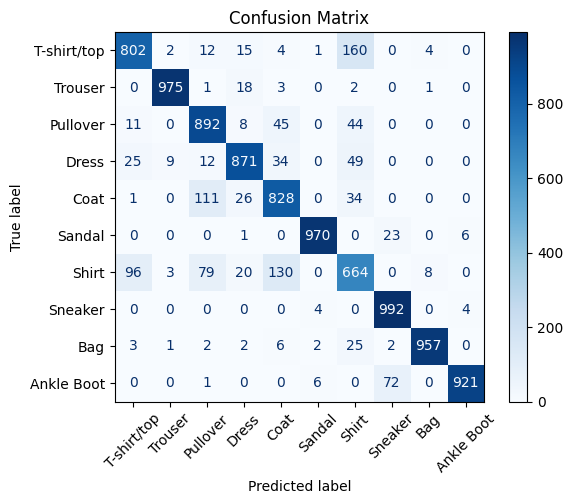

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.80      0.83      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.80      0.89      0.85      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.68      0.66      0.67      1000
     Sneaker       0.91      0.99      0.95      1000
         Bag       0.99      0.96      0.97      1000
  Ankle Boot       0.99      0.92      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [194]:
# Accuracy
accuracy = np.mean(np.array(all_labels) == np.array(all_preds))
print(f"\nTest Accuracy: {accuracy*100:.2f}%\n")

# Confusion matrix
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Classification report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:\n")
print(report)

In [104]:
### First version results:

#Epoch [1/10], Loss: 0.4219, Accuracy: 85.26%
#Epoch [2/10], Loss: 0.3288, Accuracy: 88.36%
#Epoch [3/10], Loss: 0.3166, Accuracy: 88.75%
#Epoch [4/10], Loss: 0.3111, Accuracy: 88.95%
#Epoch [5/10], Loss: 0.3019, Accuracy: 89.20%
#Epoch [6/10], Loss: 0.2894, Accuracy: 89.50%
#Epoch [7/10], Loss: 0.2907, Accuracy: 89.48%
#Epoch [8/10], Loss: 0.2806, Accuracy: 90.01%


#Classification Report:
#
#              precision    recall  f1-score   support
#
# T-shirt/top       0.84      0.81      0.83      1000
#     Trouser       0.98      0.97      0.98      1000
#    Pullover       0.76      0.81      0.78      1000
#       Dress       0.86      0.90      0.88      1000
#        Coat       0.82      0.69      0.75      1000
#      Sandal       0.97      0.96      0.96      1000
#       Shirt       0.62      0.68      0.65      1000
#     Sneaker       0.93      0.96      0.95      1000
#         Bag       0.97      0.96      0.97      1000
#  Ankle Boot       0.96      0.96      0.96      1000

#    accuracy                           0.87     10000
#   macro avg       0.87      0.87      0.87     10000
#weighted avg       0.87      0.87      0.87     10000

In [ ]:
## Second version (with regularization) results:
# 
# Test Accuracy: 87.16%
#
# Classification Report:
#
#               precision    recall  f1-score   support

#  T-shirt/top       0.88      0.75      0.81      1000
#      Trouser       1.00      0.95      0.98      1000
#     Pullover       0.78      0.72      0.75      1000
#        Dress       0.87      0.90      0.89      1000
#         Coat       0.73      0.83      0.78      1000
#       Sandal       0.98      0.97      0.98      1000
#        Shirt       0.64      0.70      0.67      1000
#      Sneaker       0.93      0.98      0.96      1000
#          Bag       0.98      0.97      0.98      1000
#   Ankle Boot       0.98      0.94      0.96      1000

#     accuracy                           0.87     10000
#    macro avg       0.88      0.87      0.87     10000
# weighted avg       0.88      0.87      0.87     10000



In [ ]:
## Third version: 16 hidden units
# Epoch [1/8], Loss: 0.9226, Accuracy: 65.04%
# Epoch [2/8], Loss: 0.5945, Accuracy: 77.81%
# Epoch [3/8], Loss: 0.5060, Accuracy: 81.35%
# Epoch [4/8], Loss: 0.4677, Accuracy: 83.14%
# Epoch [5/8], Loss: 0.4352, Accuracy: 84.23%
# Epoch [6/8], Loss: 0.4217, Accuracy: 84.92%
# Epoch [7/8], Loss: 0.4317, Accuracy: 84.46%
# Epoch [8/8], Loss: 0.4171, Accuracy: 85.19%

# Classification Report:

#               precision    recall  f1-score   support

#  T-shirt/top       0.86      0.80      0.83      1000
#      Trouser       0.98      0.97      0.98      1000
#     Pullover       0.80      0.89      0.85      1000
#        Dress       0.91      0.87      0.89      1000
#         Coat       0.79      0.83      0.81      1000
#       Sandal       0.99      0.97      0.98      1000
#        Shirt       0.68      0.66      0.67      1000
#      Sneaker       0.91      0.99      0.95      1000
#          Bag       0.99      0.96      0.97      1000
#   Ankle Boot       0.99      0.92      0.95      1000

#     accuracy                           0.89     10000
#    macro avg       0.89      0.89      0.89     10000
# weighted avg       0.89      0.89      0.89     10000